In [1]:
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [2]:
# read the veteran dataset
df = pd.read_csv('dataset_ifn580_262_v1.csv')

# show all columns information
print(df.convert_dtypes().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  string
 1   passanger             12684 non-null  string
 2   weather               12684 non-null  string
 3   temperature           12434 non-null  Int64 
 4   time                  12684 non-null  string
 5   coupon                12684 non-null  string
 6   expiration            12684 non-null  string
 7   gender                12684 non-null  string
 8   age                   12684 non-null  string
 9   maritalStatus         12684 non-null  string
 10  has_children          12684 non-null  Int64 
 11  education             12684 non-null  string
 12  occupation            12684 non-null  string
 13  income                12684 non-null  string
 14  car                   108 non-null    string
 15  Bar                   12577 non-null

In [3]:
## Assign Data Types

In [4]:
#Find the tpes of data within 
mixed_type_cols = []
for col in df.columns:
    print(df[col].apply(type).value_counts())
    print("-" * 40)
    unique_types = df[col].apply(type).value_counts()
    if len(unique_types) > 1:
        mixed_type_cols.append(col)

destination
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
passanger
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
weather
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
temperature
<class 'float'>    12684
Name: count, dtype: int64
----------------------------------------
time
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
coupon
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
expiration
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
gender
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
age
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
maritalStatus
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
has_chil

In [5]:
# find cols with multiple data types

print('Columns with multiple object types:', mixed_type_cols)

Columns with multiple object types: ['car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']


In [6]:
for name in df.columns:
    print(f'_{name}________________________________________')
    print(df[name].unique())

_destination________________________________________
['No Urgent Place' 'Home' 'Work']
_passanger________________________________________
['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
_weather________________________________________
['Sunny' 'Rainy' 'Snowy']
_temperature________________________________________
[55. 80. nan 30.]
_time________________________________________
['2PM' '10AM' '6PM' '7AM' '10PM']
_coupon________________________________________
['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
_expiration________________________________________
['1d' '2h']
_gender________________________________________
['Female' 'Male']
_age________________________________________
['21' '46' '26' '31' '41' '50plus' '36' 'below21']
_maritalStatus________________________________________
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
_has_children________________________________________
[1 0]
_education________________________________________

In [7]:
## changing datatypes to bool


In [8]:
## looking at what kind of values can be found in each column
for name in df.columns:
    print(f'_{name}________________________________________')
    print(df[name].unique())

_destination________________________________________
['No Urgent Place' 'Home' 'Work']
_passanger________________________________________
['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
_weather________________________________________
['Sunny' 'Rainy' 'Snowy']
_temperature________________________________________
[55. 80. nan 30.]
_time________________________________________
['2PM' '10AM' '6PM' '7AM' '10PM']
_coupon________________________________________
['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
_expiration________________________________________
['1d' '2h']
_gender________________________________________
['Female' 'Male']
_age________________________________________
['21' '46' '26' '31' '41' '50plus' '36' 'below21']
_maritalStatus________________________________________
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
_has_children________________________________________
[1 0]
_education________________________________________

In [9]:
## To Change
#time - datetime or an int (0-23)
#age - ordinal
#education - ordinal
#income - ordinal
#has_children - bool
#20-25 - bool


In [10]:
# Changing the innapropriate data types
# Create a swapping the variables for the hours
df.loc[df['time'] == '7AM', 'time'] = '7'
df.loc[df['time'] == '10AM', 'time'] = '10'
df.loc[df['time'] == '2PM', 'time'] = '14'
df.loc[df['time'] == '6PM', 'time'] = '18'
df.loc[df['time'] == '10PM', 'time'] = '22'

In [11]:
print(df['time'].value_counts(dropna=False))

time
18    3230
7     3164
10    2275
14    2009
22    2006
Name: count, dtype: int64


In [12]:
# swapped the categorical string values of age for ordinal values, below21 and 50plus where swapped with 16 and 51
df.loc[df['age'] == 'below21', 'age'] = '16'
df.loc[df['age'] == '21', 'age'] = '21'
df.loc[df['age'] == '26', 'age'] = '26'
df.loc[df['age'] == '31', 'age'] = '31'
df.loc[df['age'] == '36', 'age'] = '36'
df.loc[df['age'] == '41', 'age'] = '41'
df.loc[df['age'] == '46', 'age'] = '46'
df.loc[df['age'] == '50plus', 'age'] = '51'

In [13]:
print(df['age'].value_counts(dropna=False))

age
21    2653
26    2559
31    2039
51    1788
36    1319
41    1093
46     686
16     547
Name: count, dtype: int64


In [14]:
edu_order = ['Some High School', 'High School Graduate', 'Some college - no degree',
            'Associates degree', 'Bachelors degree', 'Graduate degree (Masters or Doctorate)']
df['education'] = pd.Categorical(
    df["education"],
    categories=edu_order,
    ordered=True)

In [15]:
print(df['education'].value_counts(dropna=False, sort=False))

education
Some High School                            88
High School Graduate                       905
Some college - no degree                  4351
Associates degree                         1153
Bachelors degree                          4335
Graduate degree (Masters or Doctorate)    1852
Name: count, dtype: int64


In [16]:
inc_order = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999',
            '$50000 - $62499', '$62500 - $74999', '$75000 - $87499', '$87500 - $99999',
            '$100000 or More']
df['income'] = pd.Categorical(
    df["income"],
    categories=inc_order,
    ordered=True)
print(df['income'].value_counts(dropna=False, sort=False))

income
Less than $12500    1042
$12500 - $24999     1831
$25000 - $37499     2013
$37500 - $49999     1805
$50000 - $62499     1659
$62500 - $74999      846
$75000 - $87499      857
$87500 - $99999      895
$100000 or More     1736
Name: count, dtype: int64


In [17]:
# Change gender into binary 0/1 variable.
gender_map = {'Female':0, 'Male': 1}
df['gender'] = df['gender'].map(gender_map)

# Change has_children into binary 0/1 variable.
has_children_map = {'0':0, '1': 1}
df['has_children'] = df['has_children'].astype(bool)

# Change toCoupon_GEQ5min into binary 0/1 variable.
df['toCoupon_GEQ5min'] = df['toCoupon_GEQ5min'].astype(bool)

# Change toCoupon_GEQ15min into binary 0/1 variable.
df['toCoupon_GEQ15min'] = df['toCoupon_GEQ15min'].astype(bool)

# Change toCoupon_GEQ25min into binary 0/1 variable.
df['toCoupon_GEQ25min'] = df['toCoupon_GEQ25min'].astype(bool)

# Change direction_same into binary 0/1 variable.
df['direction_same'] = df['direction_same'].astype(bool)

# Change direction_opp into binary 0/1 variable.
df['direction_opp'] = df['direction_opp'].astype(bool)


In [18]:
print(df['gender'].value_counts(dropna=False, sort=False))
print("-" * 40)
print(df['has_children'].value_counts(dropna=False, sort=False))
print("-" * 40)
print(df['toCoupon_GEQ5min'].value_counts(dropna=False, sort=False))
print("-" * 40)
print(df['toCoupon_GEQ15min'].value_counts(dropna=False, sort=False))
print("-" * 40)
print(df['toCoupon_GEQ25min'].value_counts(dropna=False, sort=False))
print("-" * 40)
print(df['direction_same'].value_counts(dropna=False, sort=False))
print("-" * 40)
print(df['direction_opp'].value_counts(dropna=False, sort=False))
print("-" * 40)

gender
0    6511
1    6173
Name: count, dtype: int64
----------------------------------------
has_children
True     5253
False    7431
Name: count, dtype: int64
----------------------------------------
toCoupon_GEQ5min
True    12684
Name: count, dtype: int64
----------------------------------------
toCoupon_GEQ15min
False    5562
True     7122
Name: count, dtype: int64
----------------------------------------
toCoupon_GEQ25min
False    11173
True      1511
Name: count, dtype: int64
----------------------------------------
direction_same
False    9960
True     2724
Name: count, dtype: int64
----------------------------------------
direction_opp
True     9960
False    2724
Name: count, dtype: int64
----------------------------------------


In [19]:
## checking for data quality issues

In [20]:
def show_unique_values(df):
    for column_name in df:
        unique_values = df[column_name].value_counts(dropna=False)
        print(f"Unique values and their counts for column '{column_name}':\n{unique_values}")

def check_missing_values(df):
    missing_values = df.isnull().sum()
    print("\nPercentage of missing values: data frame has (",len(df), 'rows)')
    for name, values in missing_values.items():
        if values > 0:
            print(name, ":", values ,' with null values')

In [21]:
show_unique_values(df)

Unique values and their counts for column 'destination':
destination
No Urgent Place    6283
Home               3237
Work               3164
Name: count, dtype: int64
Unique values and their counts for column 'passanger':
passanger
Alone        7305
Friend(s)    3298
Partner      1075
Kid(s)       1006
Name: count, dtype: int64
Unique values and their counts for column 'weather':
weather
Sunny    10069
Snowy     1405
Rainy     1210
Name: count, dtype: int64
Unique values and their counts for column 'temperature':
temperature
80.0    6399
55.0    3759
30.0    2276
NaN      250
Name: count, dtype: int64
Unique values and their counts for column 'time':
time
18    3230
7     3164
10    2275
14    2009
22    2006
Name: count, dtype: int64
Unique values and their counts for column 'coupon':
coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64
Unique values and th

In [26]:
# columns with missing values and their counts
#temp - NaN 250
#car - NaN 12576
#bar - NaN 107
#CoffeeHouse - NaN 217
#CarryAway - NaN 151
#Rest20 - NaN 130
#Rest50 - NaN 189
NANcolumns_to_list = df.columns[df.count() < len(df)].tolist()
print(NANcolumns_to_list)

['temperature', 'car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']


In [27]:
for col in NANcolumns_to_list:
    unique_vals = df[col].unique().tolist()  # Get each unique values within col (includes NaN)
    unique_count = len(unique_vals)          # Count the number of unique values
    
    print(f"Column: {col}")
    print(f"Amount of unique values: {unique_count}")
    print(f"Unique values: {unique_vals}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

Column: temperature
Amount of unique values: 4
Unique values: [55.0, 80.0, nan, 30.0]
temperature
80.0    6399
55.0    3759
30.0    2276
NaN      250
Name: count, dtype: int64
----------------------------------------
Column: car
Amount of unique values: 6
Unique values: [nan, 'Scooter and motorcycle', 'crossover', 'Mazda5', 'do not drive', 'Car that is too old to install Onstar :D']
car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64
----------------------------------------
Column: Bar
Amount of unique values: 6
Unique values: ['never', 'less1', '1~3', 'gt8', nan, '4~8']
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64
------------------------------

In [28]:
#In the car category, NAN comes to roughly 99.15%, as such it is useless in terms of real information
print(df['car'].value_counts(dropna=False))

car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64


In [29]:
#Best option is to drop the car col as there is too little real information within the column
df = df.drop(columns=['car'])

In [30]:
NANcolumns_to_list = df.columns[df.count() < len(df)].tolist()
for col in NANcolumns_to_list:
    unique_vals = df[col].unique().tolist()  # Get each unique values within col (includes NaN)
    unique_count = len(unique_vals)          # Count the number of unique values
    
    print(f"Column: {col}")
    print(f"Amount of unique values: {unique_count}")
    print(f"Unique values: {unique_vals}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

Column: temperature
Amount of unique values: 4
Unique values: [55.0, 80.0, nan, 30.0]
temperature
80.0    6399
55.0    3759
30.0    2276
NaN      250
Name: count, dtype: int64
----------------------------------------
Column: Bar
Amount of unique values: 6
Unique values: ['never', 'less1', '1~3', 'gt8', nan, '4~8']
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64
----------------------------------------
Column: CoffeeHouse
Amount of unique values: 6
Unique values: ['never', 'less1', '4~8', '1~3', 'gt8', nan]
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64
----------------------------------------
Column: CarryAway
Amount of unique values: 6
Unique values: [nan, '4~8', '1~3', 'gt8', 'less1', 'never']
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64
----------------------------------

In [32]:
# due to the categorical nature of these datasets, inplemation of mode is best suited
for col in NANcolumns_to_list:
    df[col] = df[col].fillna(df[col].mode()[0])
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

temperature
80.0    6649
55.0    3759
30.0    2276
Name: count, dtype: int64
----------------------------------------
Bar
never    5304
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64
----------------------------------------
CoffeeHouse
less1    3602
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64
----------------------------------------
CarryAway
1~3      4823
4~8      4258
less1    1856
gt8      1594
never     153
Name: count, dtype: int64
----------------------------------------
RestaurantLessThan20
1~3      5506
4~8      3580
less1    2093
gt8      1285
never     220
Name: count, dtype: int64
----------------------------------------
Restaurant20To50
less1    6266
1~3      3290
never    2136
4~8       728
gt8       264
Name: count, dtype: int64
----------------------------------------


In [33]:
for col in NANcolumns_to_list:
    unique_vals = df[col].unique().tolist()  # Get each unique values within col (includes NaN)
    unique_count = len(unique_vals)          # Count the number of unique values
    
    print(f"Column: {col}")
    print(f"Amount of unique values: {unique_count}")
    print(f"Unique values: {unique_vals}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

Column: temperature
Amount of unique values: 3
Unique values: [55.0, 80.0, 30.0]
temperature
80.0    6649
55.0    3759
30.0    2276
Name: count, dtype: int64
----------------------------------------
Column: Bar
Amount of unique values: 5
Unique values: ['never', 'less1', '1~3', 'gt8', '4~8']
Bar
never    5304
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64
----------------------------------------
Column: CoffeeHouse
Amount of unique values: 5
Unique values: ['never', 'less1', '4~8', '1~3', 'gt8']
CoffeeHouse
less1    3602
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64
----------------------------------------
Column: CarryAway
Amount of unique values: 5
Unique values: ['1~3', '4~8', 'gt8', 'less1', 'never']
CarryAway
1~3      4823
4~8      4258
less1    1856
gt8      1594
never     153
Name: count, dtype: int64
----------------------------------------
Column: RestaurantLessThan20
Amount of unique values: 5
Unique value

In [ ]:
# mixed numerical and textual
#age
#(turn above 50 into 50 and below 21 into 21, then turn it into an integer)
#(this will be fixed when we normalise later)
#(take 21 (lower bound) from each, then divide by 29 (upper bound) and it is normalised)

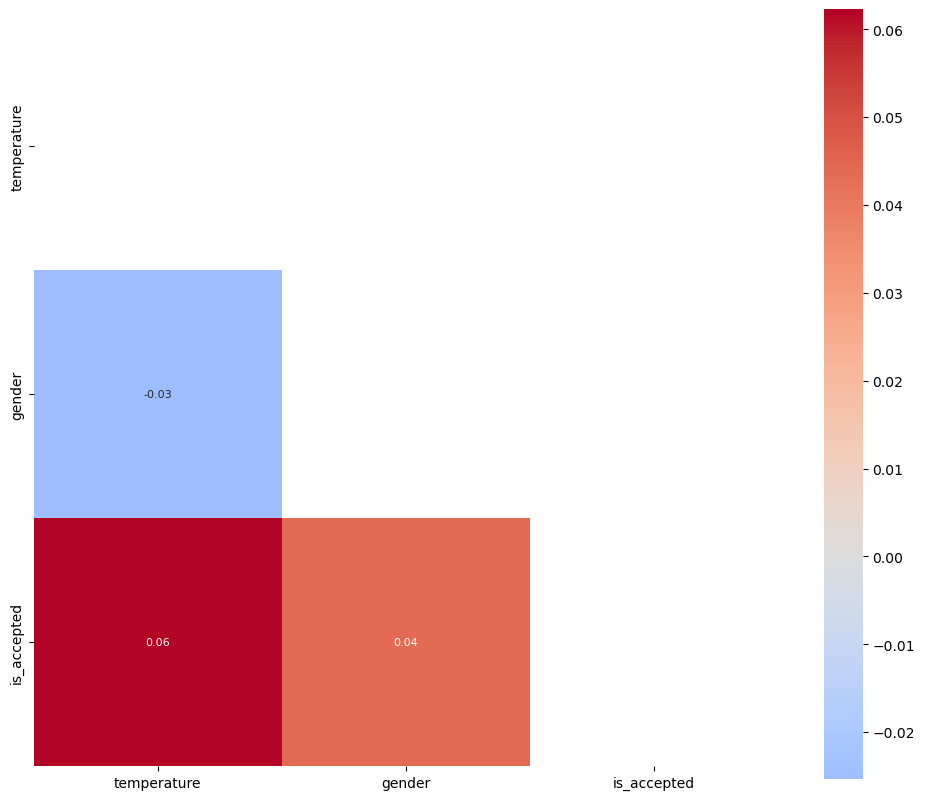

In [24]:
# Select only columns with numerical values.
numerical_columns = df.select_dtypes(include=['number'])

# Display the correlation matrix.
correlation_matrix = numerical_columns.corr()

# Create a mask for the upper triangle to avoid duplicate data
correlation_mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
plt.figure(figsize=(12, 10))
# annot=True tells seaborn to display the values for each cell.
# fmt=".2f" tells seaborn to round the values to 2 decimal places, otherwise it would not fit in the cells.
# We also adjust the font size so it fits in the page (annot_kws={'size': 8})
# center=0 tells seaborn that the middle point of the heatmap should be zero.
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
annot_kws={'size': 8}, cmap='coolwarm',
center=0, mask=correlation_mask, square=True)
plt.show()

In [25]:
del df['direction_opp']